In [16]:
%matplotlib widget

import numpy as np
from matplotlib import pyplot as plt

from scipy import signal
from scipy.signal import welch

from sklearn.decomposition import PCA

from bokeh.plotting import figure, show
from bokeh.io import output_notebook  # or use output_file("iq.html")
from bokeh.models import ColumnDataSource, LinearColorMapper, ColorBar, HoverTool, Span
from bokeh.palettes import Turbo256  # or Viridis256
output_notebook()

Loading BokehJS ...

In [17]:
def print_min_max(array):
    """
    reutrns the maximum and minimum absulute value in the array
    """
    print(f"{np.min(np.abs(array))} <-> {np.max(np.abs(array))}")


def db(value):
    """ Convert linear value to dB value """
    return 20. * np.log10(np.abs(value) + 1e-12)


def db_relative(value):
    """ Convert linear value to dB value, normalize max to 0dB """
    magnitude = np.abs(value)
    return 20. * np.log10(magnitude / np.max(magnitude) + 1e-12)

In [18]:
def plot_iq_bokeh(
    signal: np.ndarray,
    title="IQ Scatter with Time Gradient",
    p=None,
    mapper=None,
    legend_label="Signal 1"
):
    """
    Create or extend a Bokeh IQ scatter plot for a 1D complex signal
    with a time-color gradient.

    Parameters
    ----------
    signal : np.ndarray
        Complex-valued signal array (1D).
    title : str, optional
        Plot title.
    p : bokeh.plotting.figure.Figure, optional
        Existing Bokeh figure to overlay onto. If None, create a new one.
    mapper : bokeh.models.LinearColorMapper, optional
        Existing color mapper to reuse. If None, create one from this signal.
    legend_label : str, optional
        Legend label for this signal.

    Returns
    -------
    p : bokeh.plotting.figure.Figure
        The Bokeh figure handle.
    """
    if signal.ndim != 1 or not np.iscomplexobj(signal):
        raise ValueError("Input 'signal' must be a 1D complex numpy array.")

    # Prepare data
    t = np.arange(signal.size)
    x = signal.real
    y = signal.imag
    r = np.abs(signal)
    phi = np.angle(signal)

    source = ColumnDataSource(dict(
        x=x,
        y=y,
        t=t,
        mag=r,
        phase=phi
    ))

    if mapper is None:
        mapper = LinearColorMapper(
            palette=Turbo256,
            low=t.min() if signal.size else 0,
            high=t.max() if signal.size else 1
        )

    # Symmetric limits around origin with margin
    max_range = max(np.abs(x).max(), np.abs(y).max()) * 1.05 if signal.size else 1.0

    if p is None:
        x_range = (-max_range, max_range)
        y_range = (-max_range, max_range)

        p = figure(
            width=1000, height=1000,
            title=title,
            x_axis_label="I (Real)",
            y_axis_label="Q (Imag)",
            match_aspect=True,
            x_range=x_range,
            y_range=y_range,
            tools="pan,wheel_zoom,box_zoom,reset,save"
        )

        # Highlight real and imaginary axes
        x_axis_line = Span(location=0, dimension='height', line_color="black", line_width=1.2)
        y_axis_line = Span(location=0, dimension='width', line_color="black", line_width=1.2)
        p.add_layout(x_axis_line)
        p.add_layout(y_axis_line)

        # Color bar
        color_bar = ColorBar(color_mapper=mapper, label_standoff=8, title="Time index")
        p.add_layout(color_bar, "right")

        # Hover info
        p.add_tools(HoverTool(
            tooltips=[
                ("index", "@t"),
                ("I", "@x{0.000}"),
                ("Q", "@y{0.000}"),
                ("|S|", "@mag{0.000}"),
                ("∠S (rad)", "@phase{0.000}")
            ],
            mode="mouse"
        ))
    else:
        # Expand existing ranges if needed
        current_max = max(
            abs(p.x_range.start), abs(p.x_range.end),
            abs(p.y_range.start), abs(p.y_range.end)
        )
        new_max = max(current_max, max_range)
        p.x_range.start = -new_max
        p.x_range.end = new_max
        p.y_range.start = -new_max
        p.y_range.end = new_max

    # Plot points
    p.scatter(
        x="x", y="y",
        marker="circle",
        source=source,
        size=4, alpha=0.8,
        line_color=None,
        fill_color={"field": "t", "transform": mapper},
        legend_label=legend_label
    )

    return p

In [19]:
def pca_remove_components(real, imag, remove_idxs, standardize=False):
    """
    real, imag: arrays (n, k)
    remove_idxs: iterable of PC indices to remove (0-based, after sklearn's ordering by variance)
    standardize: if True, z-score features before PCA and unscale after
    Returns reconstructed real/imag with selected PCs removed.
    """
    n, k = real.shape
    X = np.hstack([real, imag])             # (n, 2k)

    # center (always)
    mu = X.mean(axis=0, keepdims=True)
    Xc = X - mu

    # optional standardization to equalize channel scales
    if standardize:
        sigma = Xc.std(axis=0, keepdims=True)
        sigma[sigma == 0] = 1.0
        Xc_std = Xc / sigma
    else:
        Xc_std = Xc

    # PCA fit
    pca = PCA(svd_solver="full")
    Z = pca.fit_transform(Xc_std)           # (n, 2k), scores (time courses)

    # remove arbitrary components
    Z_f = Z.copy()
    Z_f[:, list(remove_idxs)] = 0.0

    # inverse transform
    Xc_std_rec = pca.inverse_transform(Z_f)

    # unscale / uncenter
    if standardize:
        Xc_rec = Xc_std_rec * sigma
    else:
        Xc_rec = Xc_std_rec
    X_rec = Xc_rec + mu

    # split back to complex parts
    real_rec = X_rec[:, :k]
    imag_rec = X_rec[:, k:]
    return real_rec, imag_rec

In [20]:
gen1_I = np.load('gen1_0dB/loopback_II_6ullged0_20260320T212449Z.npy')
gen1_Q = np.load('gen1_0dB/loopback_QQ_vxiv3ho2_20260320T212449Z.npy')
gen1_channel_count = np.load('gen1_0dB/loopback_channel_counts_xgmm08a8_20260320T212449Z.npy')
gen1_packet_count = np.load('gen1_0dB/loopback_packet_counts_gey656_z_20260320T212449Z.npy')
gen1_packet_info = np.load('gen1_0dB/loopback_packet_infos_an3gs6pl_20260320T212449Z.npy')
gen1_packet_ips = np.load('gen1_0dB/loopback_packet_ips_4tayawz5_20260320T212449Z.npy')
gen1_packet_ptp = np.load('gen1_0dB/loopback_ptp_timestamps_0hauts92_20260320T212449Z.npy')

gen2_I = np.load('gen2_0dB/loopback_II_j89itdvg_20260320T200258Z.npy')
gen2_Q = np.load('gen2_0dB/loopback_QQ_2wee6yif_20260320T200258Z.npy')
gen2_channel_count = np.load('gen2_0dB/loopback_channel_counts_4i9elspj_20260320T200258Z.npy')
gen2_packet_count = np.load('gen2_0dB/loopback_packet_counts_boe1rabq_20260320T200258Z.npy')
gen2_packet_info = np.load('gen2_0dB/loopback_packet_infos_10tyx7tq_20260320T200258Z.npy')
gen2_packet_ips = np.load('gen2_0dB/loopback_packet_ips_uuirsilm_20260320T200258Z.npy')
gen2_packet_ptp = np.load('gen2_0dB/loopback_ptp_timestamps_2ikvhva9_20260320T200258Z.npy')

In [21]:
gen1_timeStream = gen1_I + 1.j * gen1_Q
gen2_timeStream = gen2_I + 1.j * gen2_Q

print("Gen1 I/Q shapes:", gen1_I.shape, gen1_Q.shape)
print("Gen1 channel count:", gen1_channel_count)
print("Gen2 channel count:", gen2_channel_count)

Gen1 I/Q shapes: (29280, 1024) (29280, 1024)
Gen1 channel count: [435 435 435 ... 435 435 435]
Gen2 channel count: [271 271 271 ... 271 271 271]


In [22]:
gen1_I_filtered, gen1_Q_filtered = pca_remove_components(gen1_I, gen1_Q, [0,1,2,3,4])
gen2_I_filtered, gen2_Q_filtered = pca_remove_components(gen2_I, gen2_Q, [0,1,2,3,4])
gen1_timeStream_filtered = gen1_I_filtered + 1.j * gen1_Q_filtered
gen2_timeStream_filtered = gen2_I_filtered + 1.j * gen2_Q_filtered

In [23]:
data = gen1_timeStream[0:500, 0:272]   # shape (n, n_channels)
n_samples, n_channels = data.shape

p = figure(
    title="Multi-channel IQ Scatter",
    x_axis_label="I (Real)",
    y_axis_label="Q (Imag)",
    width=1000,
    height=1000,
    tools="pan,wheel_zoom,box_zoom,reset,hover"
)

def channel_color(ch, total):
    return Turbo256[int(ch / max(total - 1, 1) * 255)]

for ch in range(n_channels):
    signal = data[:, ch]

    src = ColumnDataSource(dict(
        x=signal.real,
        y=signal.imag,
        t=np.arange(n_samples),
        ch=np.full(n_samples, ch)
    ))

    p.scatter(
        x="x", y="y",
        source=src,
        size=4,
        alpha=0.6,
        color=channel_color(ch, n_channels)
    )

p.add_layout(Span(location=0, dimension="width", line_color="black", line_width=1))
p.add_layout(Span(location=0, dimension="height", line_color="black", line_width=1))

p.add_tools(HoverTool(tooltips=[
    ("Channel", "@ch"),
    ("I", "@x{0.000}"),
    ("Q", "@y{0.000}"),
    ("t", "@t")
]))

show(p)

In [24]:
data = gen2_timeStream[0:500, 0:272]   # shape (n, n_channels)

n_samples, n_channels = data.shape

p = figure(
    title="Multi-channel IQ Scatter",
    x_axis_label="I (Real)",
    y_axis_label="Q (Imag)",
    width=1000,
    height=1000,
    tools="pan,wheel_zoom,box_zoom,reset,hover"
)

def channel_color(ch, total):
    return Turbo256[int(ch / max(total - 1, 1) * 255)]

for ch in range(n_channels):
    signal = data[:, ch]

    src = ColumnDataSource(dict(
        x=signal.real,
        y=signal.imag,
        t=np.arange(n_samples),
        ch=np.full(n_samples, ch)
    ))

    p.scatter(
        x="x", y="y",
        source=src,
        size=4,
        alpha=0.6,
        color=channel_color(ch, n_channels)
    )

p.add_layout(Span(location=0, dimension="width", line_color="black", line_width=1))
p.add_layout(Span(location=0, dimension="height", line_color="black", line_width=1))

p.add_tools(HoverTool(tooltips=[
    ("Channel", "@ch"),
    ("I", "@x{0.000}"),
    ("Q", "@y{0.000}"),
    ("t", "@t")
]))

show(p)

In [25]:
but = 18  # bin under test

sig1 = gen1_timeStream[0:500, but]
sig2 = gen2_timeStream[0:500, but]

p = plot_iq_bokeh(sig1, legend_label="gen1")

t2 = np.arange(sig2.size)
src2 = ColumnDataSource(dict(
    x=sig2.real,
    y=sig2.imag,
    t=t2,
    mag=np.abs(sig2),
    phase=np.angle(sig2)
))

mapper2 = LinearColorMapper(palette=Turbo256, low=t2.min(), high=t2.max())

p.scatter(
    x="x", y="y",
    marker="circle",
    source=src2,
    size=4, alpha=0.8,
    line_color=None,
    fill_color={"field": "t", "transform": mapper2},
    legend_label="gen2"
)
p.legend.click_policy = "hide"
show(p)

SNR in each bin (gen1): 
 [67.8176532  68.43525798 65.75280924 57.68439589 62.94744589 66.71416818
 69.51184946 68.80291148 66.70537574 62.33566331 55.5217827  64.73803333
 66.91825849 68.71421749 68.90926165 66.22009559 62.27735808 50.28426094
 50.30965909 61.1930399  68.01201385 68.28757541 68.63700379 55.03512631
 35.96568948 58.54627276 65.45889496 67.64811433 67.82453248 67.35215621
 66.67093693 65.36183194]


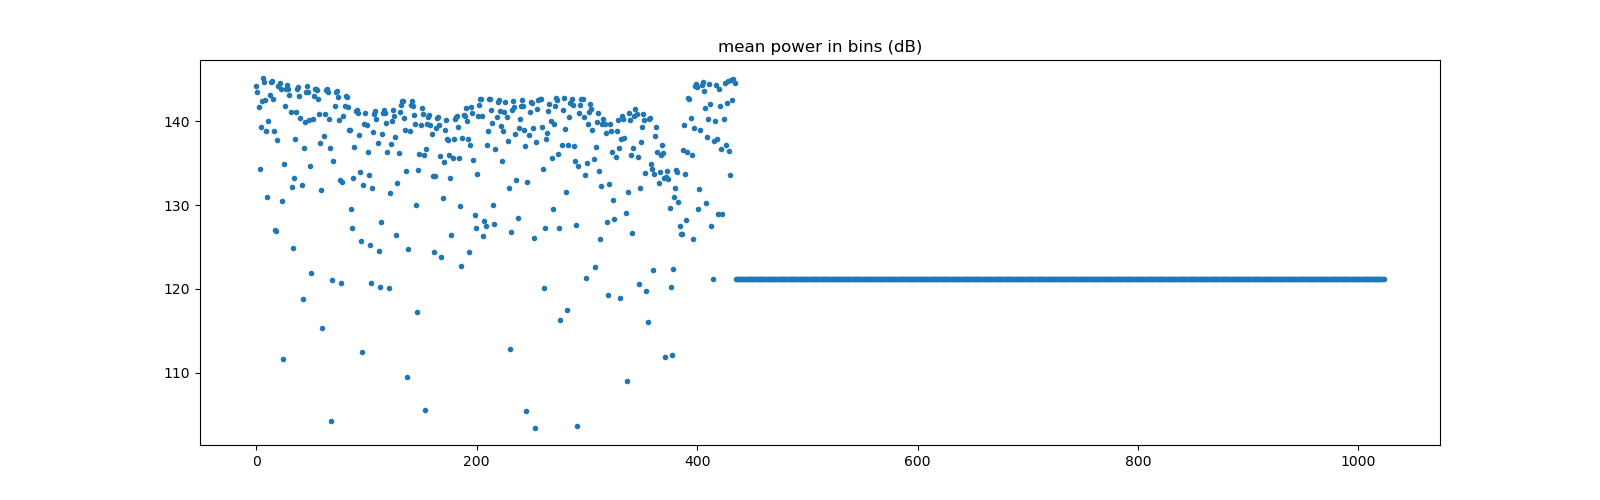

In [26]:
sampling_rate = 1.024e9/(2048*1024)  # Hz
gen1_power = np.abs(gen1_timeStream)**2

mean_power = np.mean(gen1_power, axis=0)
variance = np.var(gen1_timeStream.real, axis=0) + np.var(gen1_timeStream.imag, axis=0)
SNR = mean_power / variance
SNR_dBperHz = 10*np.log10(SNR) + 10*np.log10(sampling_rate)
print("SNR in each bin (gen1): \n", SNR_dBperHz[0:32])

plt.figure(figsize=(16, 5))
plt.title("mean power in bins (dB)")
plt.plot(10*np.log10(mean_power[0:1024]), '.')
# for x in bin_map:
#     plt.axvline(x=x, color='grey', linestyle='-', alpha=0.5)
# plt.axvline(x=532, color='grey', linestyle='--')
# plt.xlim(0, 250)
plt.show()

SNR in each bin (gen2): 
 [58.20356249 54.72656644 53.9086875  52.73769363 59.2470623  61.0699467
 57.5411327  54.34858991 56.319901   55.25691421 60.94680172 56.07779703
 58.84899331 56.94499039 54.96860955 54.80864213 61.55212983 58.66981621
 55.41859181 53.13972041 53.63883088 51.1237059  55.85782779 53.29920952
 54.22685984 53.84604252 53.10575822 58.53548561 59.22551814 57.53263493
 57.73246168 57.5965764 ]


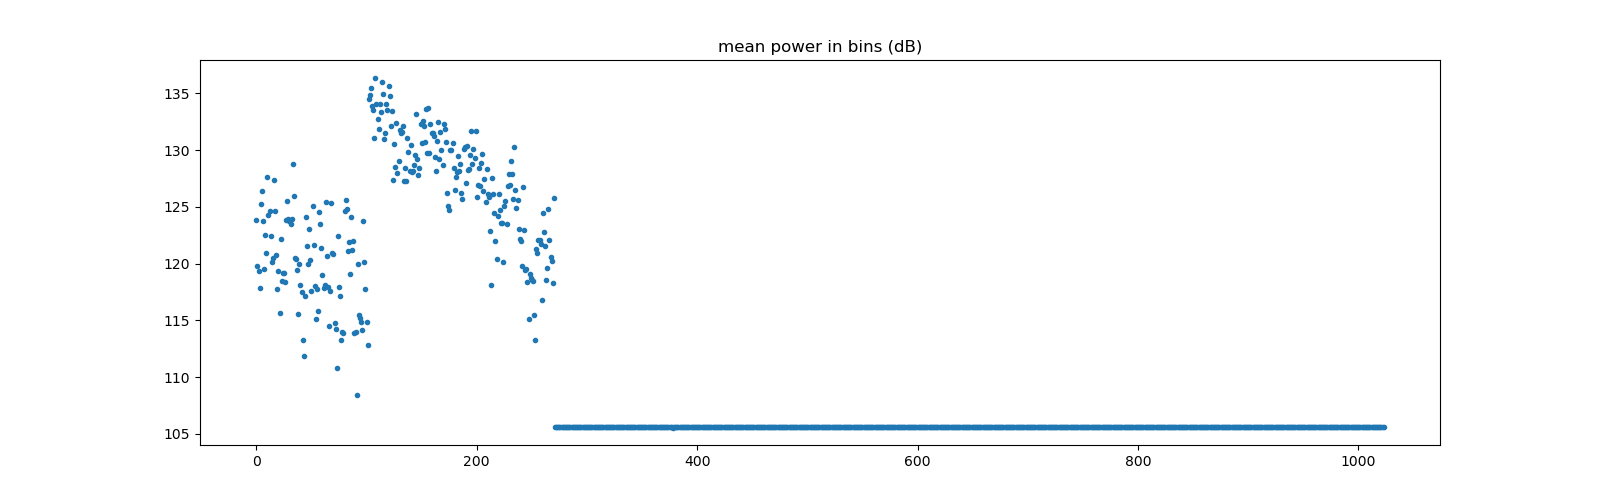

In [27]:
sampling_rate = 1.024e9/(2048*1024)  # Hz
gen2_power = np.abs(gen2_timeStream)**2

mean_power = np.mean(gen2_power, axis=0)
variance = np.var(gen2_timeStream.real, axis=0) + np.var(gen2_timeStream.imag, axis=0)
SNR = mean_power / variance
SNR_dBperHz = 10*np.log10(SNR) + 10*np.log10(sampling_rate)
print("SNR in each bin (gen2): \n", SNR_dBperHz[0:32])

plt.figure(figsize=(16, 5))
plt.title("mean power in bins (dB)")
plt.plot(10*np.log10(mean_power[0:1024]), '.')
# for x in bin_map:
#     plt.axvline(x=x, color='grey', linestyle='-', alpha=0.5)
# plt.axvline(x=532, color='grey', linestyle='--')
# plt.xlim(0, 250)
plt.show()

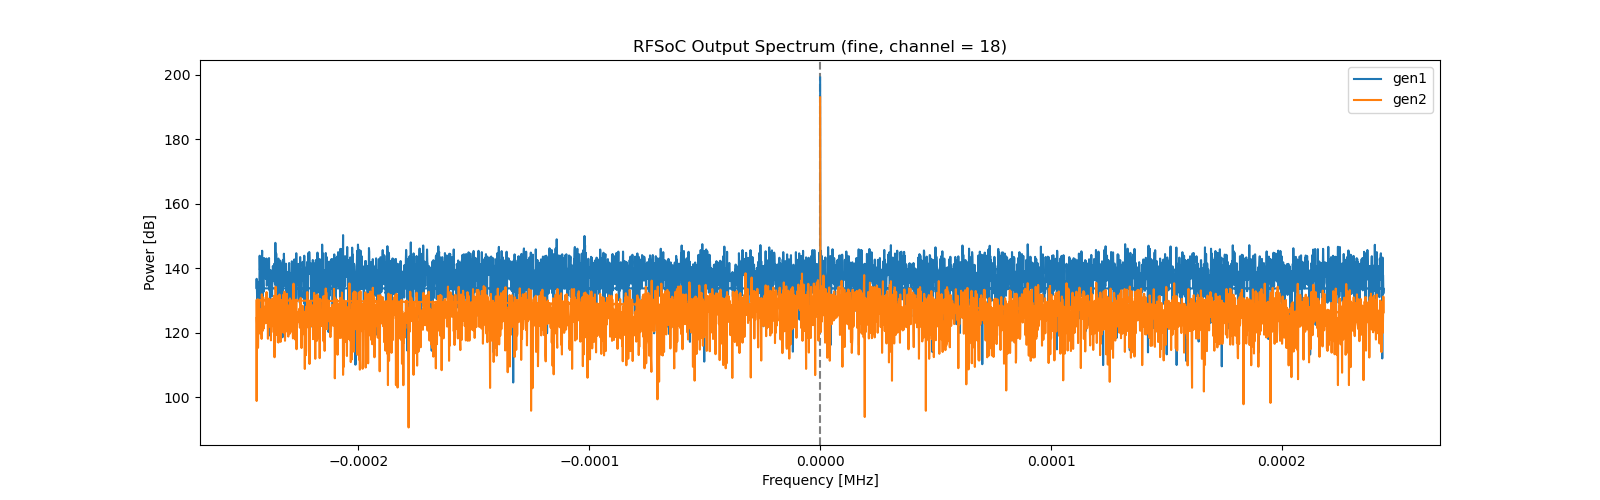

In [28]:
n_overlapped_channel = 2048
fs = 4 * 256e6
acc_factor = 1024

fft_length = 4096

plt.figure(figsize=(16, 5))
plt.title(f"RFSoC Output Spectrum (fine, channel = {but})")
plt.axvline(x=0, color='grey', linestyle='--')
xf = np.fft.fftfreq(fft_length, 1./(fs/(2048*acc_factor)))
plt.plot(xf/1e6, db(np.fft.fft(gen1_timeStream[:, but], fft_length)), label='gen1')
plt.plot(xf/1e6, db(np.fft.fft(gen2_timeStream[:, but], fft_length)), label='gen2')
plt.xlabel("Frequency [MHz]")
plt.ylabel("Power [dB]")
# plt.axhline(y=186.65, color='red', linestyle='--', label='186.65 dB')
# plt.axhline(y=100, color='green', linestyle='--', label='100 dB')
# plt.axhline(y=48, color='grey', linestyle='--', label='48 dB')
# plt.axhline(y=111, color='grey', linestyle='--', label='111 dB')

plt.legend()
plt.show()

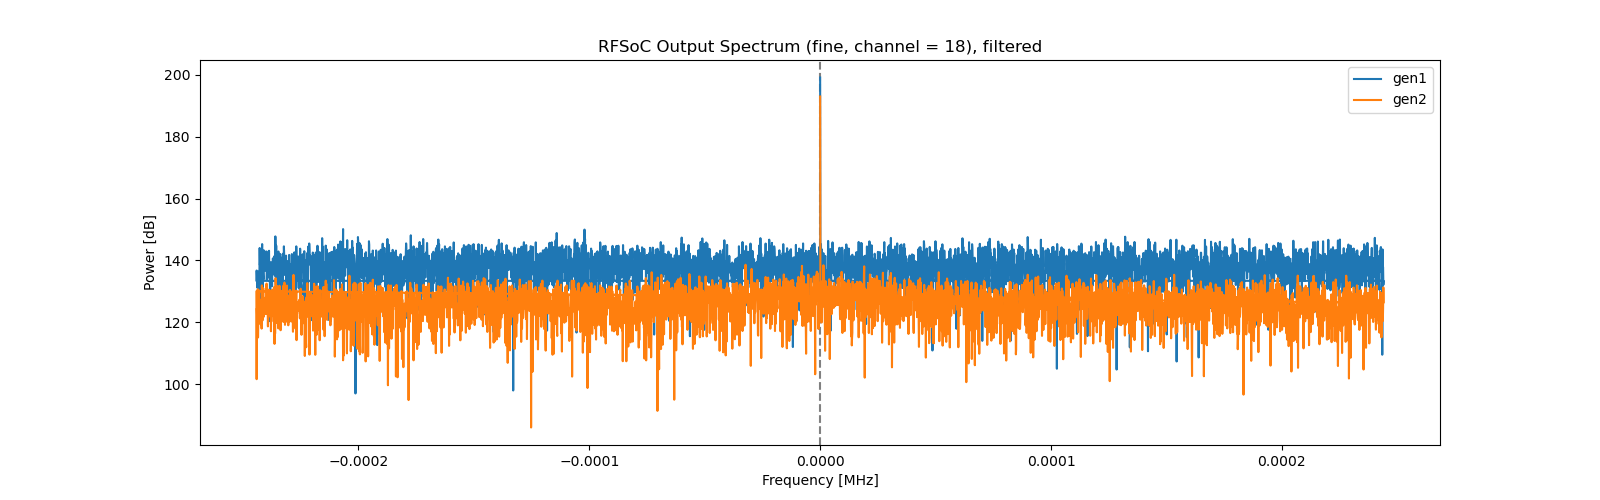

In [29]:
n_overlapped_channel = 2048
fs = 4 * 256e6
acc_factor = 1024

fft_length = 4096

plt.figure(figsize=(16, 5))
plt.title(f"RFSoC Output Spectrum (fine, channel = {but}), filtered")
plt.axvline(x=0, color='grey', linestyle='--')
xf = np.fft.fftfreq(fft_length, 1./(fs/(2048*acc_factor)))
plt.plot(xf/1e6, db(np.fft.fft(gen1_timeStream_filtered[:, but], fft_length)), label='gen1')
plt.plot(xf/1e6, db(np.fft.fft(gen2_timeStream_filtered[:, but], fft_length)), label='gen2')
plt.xlabel("Frequency [MHz]")
plt.ylabel("Power [dB]")
# plt.axhline(y=186.65, color='red', linestyle='--', label='186.65 dB')
# plt.axhline(y=100, color='green', linestyle='--', label='100 dB')
# plt.axhline(y=48, color='grey', linestyle='--', label='48 dB')
# plt.axhline(y=111, color='grey', linestyle='--', label='111 dB')

plt.legend()
plt.show()

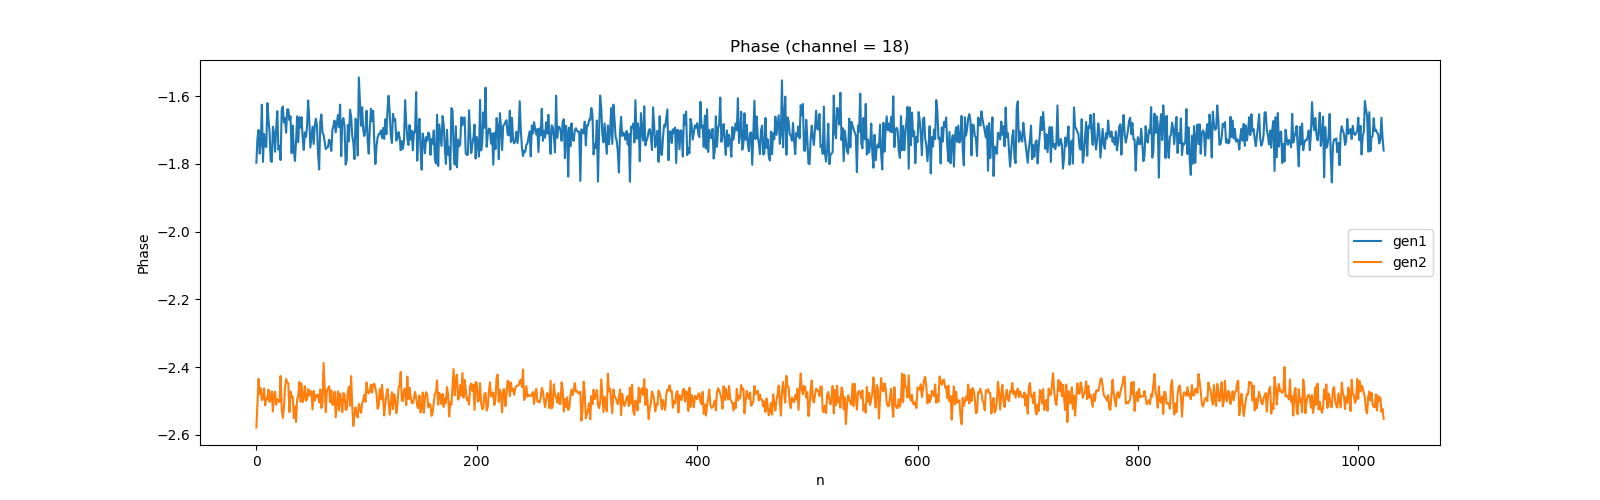

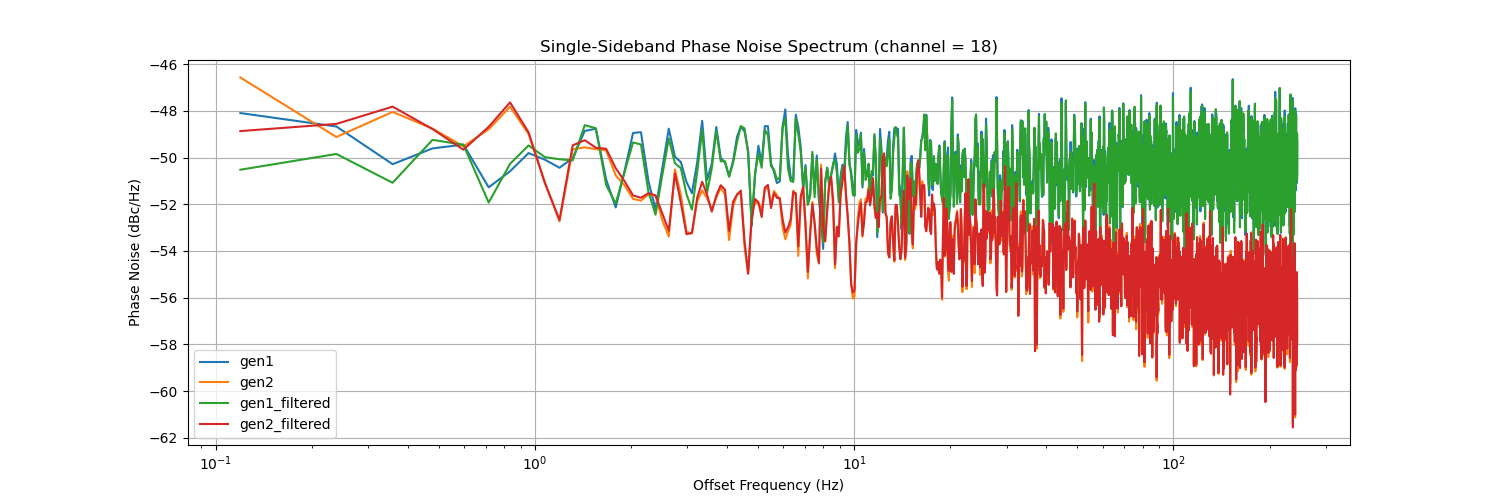

In [30]:
n_overlapped_channel = 2048
fs = 4 * 256e6
acc_factor = 1024

SUT_gen1 = gen1_timeStream[:, but]
SUT_gen2 = gen2_timeStream[:, but]
SUT_gen1_filtered = gen1_timeStream_filtered[:, but]
SUT_gen2_filtered = gen2_timeStream_filtered[:, but]

phase_gen1 = np.angle(SUT_gen1)
f, Pxx_gen1 = welch(phase_gen1, fs=fs/(n_overlapped_channel*acc_factor), nperseg=4096, scaling='density')
phase_noise_gen1 = 10 * np.log10(Pxx_gen1)

phase_gen2 = np.angle(SUT_gen2)
f, Pxx_gen2 = welch(phase_gen2, fs=fs/(n_overlapped_channel*acc_factor), nperseg=4096, scaling='density')
phase_noise_gen2 = 10 * np.log10(Pxx_gen2)

phase_gen1_filtered = np.angle(SUT_gen1_filtered)
f, Pxx_gen1_filtered = welch(phase_gen1_filtered, fs=fs/(n_overlapped_channel*acc_factor), nperseg=4096, scaling='density')
phase_noise_gen1_filtered = 10 * np.log10(Pxx_gen1_filtered)

phase_gen2_filtered = np.angle(SUT_gen2_filtered)
f, Pxx_gen2_filtered = welch(phase_gen2_filtered, fs=fs/(n_overlapped_channel*acc_factor), nperseg=4096, scaling='density')
phase_noise_gen2_filtered = 10 * np.log10(Pxx_gen2_filtered)

plt.figure(figsize=(16,5))
plt.plot(phase_gen1[0:1024], label='gen1')
plt.plot(phase_gen2[0:1024], label='gen2')
plt.xlabel("n")
plt.ylabel("Phase")
plt.title(f"Phase (channel = {but})")
plt.legend()
plt.show()

plt.figure(figsize=(15,5))
plt.semilogx(f[1:], phase_noise_gen1[1:], label='gen1')  # Ignore DC component
plt.semilogx(f[1:], phase_noise_gen2[1:], label='gen2')
plt.semilogx(f[1:], phase_noise_gen1_filtered[1:], label='gen1_filtered')
plt.semilogx(f[1:], phase_noise_gen2_filtered[1:], label='gen2_filtered')
plt.xlabel("Offset Frequency (Hz)")
plt.ylabel("Phase Noise (dBc/Hz)")
plt.title(f"Single-Sideband Phase Noise Spectrum (channel = {but})")
plt.grid(True)
plt.legend()
plt.show()